In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import time
from collections import Counter
import json
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt giao diện biểu đồ
sns.set_theme(style="whitegrid")

# KIỂM TRA PHẦN CỨNG
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {DEVICE}")

# =====================================================================
# BƯỚC 0 & MODULE 1: ĐÓNG BĂNG DỮ LIỆU VÀ WORD2VEC
# =====================================================================
def freeze_data_splits(original_csv_path, output_dir="/kaggle/working/"):
    train_path = f"{output_dir}/train_data.csv"
    val_path = f"{output_dir}/val_data.csv"
    test_path = f"{output_dir}/test_data.csv"
    
    # [LƯU Ý]: Nếu em đã chạy trước đó, hãy xóa 3 file train, val, test cũ đi 
    # (hoặc comment 3 dòng if os.path.exists này lại để ép nó chia lại từ đầu)
    if os.path.exists(train_path):
        print("-> Dữ liệu đã được chia sẵn. Bỏ qua bước này!")
        return train_path, val_path, test_path
        
    df = pd.read_csv(original_csv_path).dropna(subset=['text'])
    

    initial_len = len(df)
    
    df['text_clean'] = df['text'].astype(str).str.strip().str.lower()
    
    # Drop trùng lặp dựa trên cột text đã làm sạch
    df = df.drop_duplicates(subset=['text_clean'], keep='first')
    
    # Bỏ đi cột nháp text_clean
    df = df.drop(columns=['text_clean'])
    
    print(f"🚨 CẢNH BÁO DỮ LIỆU: Đã xóa {initial_len - len(df)} dòng bị trùng lặp nội dung!")
    print(f"-> Số lượng dữ liệu sạch còn lại: {len(df)} dòng.")
    # ==========================================
    
    y_stratify = df['tier1_labels'].map({'Clean': 0, 'Toxic': 1}).fillna(0).astype(int)
    
    df_train, df_temp, _, y_temp = train_test_split(df, y_stratify, test_size=0.2, random_state=42, stratify=y_stratify)
    df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42, stratify=y_temp)
    
    df_train.to_csv(train_path, index=False)
    df_val.to_csv(val_path, index=False)
    df_test.to_csv(test_path, index=False)
    
    print(f"-> Đã lưu File mới: Train ({len(df_train)}), Val ({len(df_val)}), Test ({len(df_test)})")
    return train_path, val_path, test_path

# --- CÁC HÀM TĂNG CƯỜNG DỮ LIỆU TIẾNG VIỆT ---
def remove_diacritics(text):
    s1 = u'ÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚÝàáâãèéêìíòóôõùúýĂăĐđĨĩŨũƠơƯưẠạẢảẤấẦầẨẩẪẫẬậẮắẰằẲẳẴẵẶặẸẹẺẻẼẽẾếỀềỂểỄễỆệỈỉỊịỌọỎỏỐốỒồỔổỖỗỘộỚớỜờỞởỠỡỢợỤụỦủỨứỪừỬửỮữỰựỲỳỴỵỶỷỸỹ'
    s0 = u'AAAAEEEIIOOOOUUYaaaaeeeiioooouuyAaDdIiUuOoUuAaAaAaAaAaAaAaAaAaAaAaAaEeEeEeEeEeEeEeEeIiIiOoOoOoOoOoOoOoOoOoOoOoOoUuUuUuUuUuUuUuUuYyYyYyYy'
    s = ''
    for c in str(text): s += s0[s1.index(c)] if c in s1 else c
    return s

EMOJIS_TOXIC = [":phẫn_nộ:", ":chửi_thề:", ":ngón_giữa:", ":cười_nhếch_mép:", ":tức_giận:", ":mặt_quỷ:"]

def inject_emoji(text, is_toxic):
    if not is_toxic: return text
    words = str(text).split()
    emoji = random.choice(EMOJIS_TOXIC)
    if random.random() < 0.8: words.append(emoji)
    else: words.insert(0, emoji)
    return " ".join(words)

SYNONYMS_DICT = {
    "bắc kỳ": ["dân bắc", "người bắc", "bắc kì"],
    "nam kỳ": ["dân nam", "người nam", "nam kì"],
    "dân 36": ["người hà nội", "dân hà thành"],
    "trung kỳ": ["dân trung", "người miền trung"],
    "người hoa": ["dân hoa kiều", "hoa kiều", "tàu"],
    "tàu": ["người tàu", "hoa kiều", "dân tàu"],
    "chệt": ["người hoa", "tàu khựa"],
    "ăn cắp": ["trộm cắp", "lấy đồ", "cướp giật"],
    "lừa đảo": ["gian lận", "dối trá", "bịp bợm"],
    "bẩn": ["dơ", "nhơ", "ô uế", "hôi hám"],
    "lười": ["lười biếng", "lười nhác", "ăn không ngồi rồi"],
    "ngu": ["đần", "ngốc", "kém cỏi", "dốt nát"],
    "xấu": ["tệ hại", "tồi tàn", "kém cỏi"],
    "toàn lũ": ["đều là lũ", "toàn bọn", "đều là bọn"],
    "bọn": ["lũ", "đám", "hội"],
    "lũ": ["bọn", "đám", "hội"],
}

def controlled_synonym_replace(text):
    words = str(text).split()
    return " ".join([random.choice(SYNONYMS_DICT[w]) if w in SYNONYMS_DICT and random.random() < 0.6 else w for w in words])

def smart_augment_vietnamese(text, is_toxic):
    choice = random.choice(['remove_accent', 'emoji', 'synonym'])
    if choice == 'remove_accent': return remove_diacritics(text)
    elif choice == 'emoji': return inject_emoji(text, is_toxic)
    elif choice == 'synonym': return controlled_synonym_replace(text)
    return text

def augment_and_plot(train_csv_path, output_path):
    print("\n" + "="*50 + "\n🚀 TIẾN HÀNH DATA AUGMENTATION (CHỈ HATE SPEECH)\n" + "="*50)
    if os.path.exists(output_path):
        print(f"-> Đã tìm thấy file augmented: {output_path}. Bỏ qua bước này.")
        return output_path
        
    df = pd.read_csv(train_csv_path).dropna(subset=['text'])
    augmented_rows = []
    
    counts_before = {'Hate Speech': 0, 'Obscene': 0, 'Harassment': 0, 'Positive': 0, 'Negative': 0, 'Neutral': 0}
    counts_after = counts_before.copy()
    
    for _, row in df.iterrows():
        augmented_rows.append(row.to_dict())
        is_toxic = (row['tier1_labels'] == 'Toxic')
        tier2_lbls = str(row['tier2_labels'])
        
        for k in counts_before.keys():
            if k in tier2_lbls: counts_before[k] += 1
            
        num_copies = 0
        # >>> CHỈ TĂNG CƯỜNG HATE SPEECH x15 <<<
        if is_toxic and 'Hate Speech' in tier2_lbls: 
            num_copies = 15
            
        for _ in range(num_copies):
            new_row = row.to_dict()
            new_row['text'] = smart_augment_vietnamese(row['text'], is_toxic=is_toxic)
            augmented_rows.append(new_row)
            
    df_aug = pd.DataFrame(augmented_rows).sample(frac=1, random_state=42).reset_index(drop=True)
    df_aug.to_csv(output_path, index=False)
    
    for lbl in df_aug['tier2_labels'].dropna():
        for k in counts_after.keys():
            if k in str(lbl): counts_after[k] += 1
            
    # VẼ BIỂU ĐỒ SO SÁNH AUGMENTATION
    labels = list(counts_before.keys())
    before = [counts_before[l] for l in labels]
    after = [counts_after[l] for l in labels]

    x = np.arange(len(labels))
    width = 0.35
    fig, ax = plt.subplots(figsize=(12, 6))
    rects1 = ax.bar(x - width/2, before, width, label='Trước Augment', color='#4c72b0')
    rects2 = ax.bar(x + width/2, after, width, label='Sau Augment', color='#dd8452')

    ax.set_ylabel('Số lượng mẫu')
    ax.set_title('So sánh Phân bổ Dữ liệu (Chỉ Augment Hate Speech)')
    ax.set_xticks(x); ax.set_xticklabels(labels); ax.legend()
    
    for rects in [rects1, rects2]:
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height}', xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig('/kaggle/working/augmentation_comparison.png', dpi=300)
    plt.show()
    print("✅ Đã hoàn thành Augmentation chuyên biệt cho Hate Speech.")
    return output_path

# =====================================================================
# MODULE 1: HUẤN LUYỆN SKIP-GRAM
# =====================================================================
def train_skipgram_optimized(train_csv_path, save_w2v_path, save_vocab_path):
    print("\n" + "="*50 + "\nPHA 1: HUẤN LUYỆN WORD2VEC TRÊN TẬP TRAIN\n" + "="*50)
    df_train = pd.read_csv(train_csv_path).dropna(subset=['text'])
    sentences = df_train['text'].apply(lambda x: str(x).split()).tolist()
    
    word_counts = Counter(word for sentence in sentences for word in sentence)
    vocab = {"<PAD>": 0, "<UNK>": 1}
    for word, count in word_counts.items():
        if count >= 2: vocab[word] = len(vocab)
        
    with open(save_vocab_path, 'w', encoding='utf-8') as f: json.dump(vocab, f, ensure_ascii=False)
    
    corpus_ids = [[vocab.get(w, 1) for w in sent] for sent in sentences if len(sent) >= 2]
    
    total_estimated = sum([len(sent) * 10 for sent in corpus_ids]) 
    targets_np, contexts_np = np.zeros(total_estimated, dtype=np.int32), np.zeros(total_estimated, dtype=np.int32)
    
    idx = 0
    for sent in corpus_ids:
        n = len(sent)
        for i, target in enumerate(sent):
            for j in range(max(0, i - 5), min(n, i + 6)):
                if i != j:
                    targets_np[idx], contexts_np[idx] = target, sent[j]
                    idx += 1
                    
    targets_tensor = torch.from_numpy(targets_np[:idx]).long()
    contexts_tensor = torch.from_numpy(contexts_np[:idx]).long()
    del targets_np, contexts_np
    
    class SGNSModel(nn.Module):
        def __init__(self, V, D=300):
            super().__init__()
            self.W_t, self.W_c = nn.Embedding(V, D, padding_idx=0), nn.Embedding(V, D, padding_idx=0)
            self.W_t.weight.data.uniform_(-0.01, 0.01); self.W_c.weight.data.uniform_(-0.01, 0.01)

        def forward(self, t, c, n):
            v_t, u_c, u_n = self.W_t(t), self.W_c(c), self.W_c(n)
            pos_loss = -F.logsigmoid((v_t * u_c).sum(1))
            neg_loss = -F.logsigmoid(-torch.bmm(v_t.unsqueeze(1), u_n.transpose(1, 2)).squeeze(1)).sum(1)
            return (pos_loss + neg_loss).mean()

    model = SGNSModel(len(vocab)).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    BATCH_SIZE, total_pairs = 32768, len(targets_tensor)
    
    for epoch in range(5): 
        perm = torch.randperm(total_pairs)
        t_tensor, c_tensor = targets_tensor[perm], contexts_tensor[perm]
        for i in range(0, total_pairs, BATCH_SIZE):
            b_t = t_tensor[i:i+BATCH_SIZE].to(DEVICE, non_blocking=True)
            b_c = c_tensor[i:i+BATCH_SIZE].to(DEVICE, non_blocking=True)
            b_n = torch.randint(0, len(vocab), (b_t.size(0), 5), device=DEVICE)
            optimizer.zero_grad(); loss = model(b_t, b_c, b_n); loss.backward(); optimizer.step()
    np.save(save_w2v_path, model.W_t.weight.data.cpu().numpy())

# =====================================================================
# MODULE 2: MÔ HÌNH C-LSTM VÀ ĐÁNH GIÁ
# =====================================================================
class HierarchicalDataset(Dataset):
    def __init__(self, X, yt, ys, yd):
        self.X, self.yt, self.ys, self.yd = torch.tensor(X, dtype=torch.long), torch.tensor(yt, dtype=torch.float32), torch.tensor(ys, dtype=torch.long), torch.tensor(yd, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.yt[i], self.ys[i], self.yd[i]

def build_dataloader(csv_path, vocab, batch_size=512, shuffle=False):
    df = pd.read_csv(csv_path).dropna(subset=['text'])
    df['label_toxic'] = df['tier1_labels'].map({'Clean': 0, 'Toxic': 1}).fillna(-1).astype(int)

    
    sentiment_map = df['tier2_labels'].map({'Negative': 0, 'Neutral': 1, 'Positive': 2})
    df['label_sentiment'] = np.where(df['tier1_labels'] == 'Clean', sentiment_map, -1)
    df['label_sentiment'] = df['label_sentiment'].fillna(-1).astype(int)
    
    
    def encode_toxic(label):
        if pd.isna(label) or label in ['Negative', 'Neutral', 'Positive']: return [0, 0, 0]
        return [1 if 'Harassment' in str(label) else 0, 1 if 'Obscene' in str(label) else 0, 1 if 'Hate Speech' in str(label) else 0]
    df['label_toxic_details'] = df['tier2_labels'].apply(encode_toxic)
    
    X_seq = np.array(df['text'].apply(lambda x: ([vocab.get(w, vocab["<UNK>"]) for w in str(x).split()][:50] + [vocab["<PAD>"]] * 50)[:50]).tolist())
    return DataLoader(HierarchicalDataset(X_seq, df['label_toxic'].values, df['label_sentiment'].values, np.array(df['label_toxic_details'].tolist())), batch_size=batch_size, shuffle=shuffle)

class C_LSTM_Model(nn.Module):
    def __init__(self, vocab_size, w2v_path):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, 300, padding_idx=0)
        self.emb.weight.data.copy_(torch.from_numpy(np.load(w2v_path)))
        self.lstm = nn.LSTM(300, 128, batch_first=True, bidirectional=True)
        self.convs = nn.ModuleList([nn.Conv1d(256, 100, k) for k in [3,4,5]])
        self.drop = nn.Dropout(0.5)
        self.h_tox, self.h_sent, self.h_tdet = nn.Linear(300, 1), nn.Linear(300, 3), nn.Linear(300, 3)

    def forward(self, x):
        lstm_out, _ = self.lstm(self.emb(x))
        cnn_in = lstm_out.permute(0, 2, 1) 
        feat = self.drop(torch.cat([F.max_pool1d(F.relu(c(cnn_in)), c(cnn_in).shape[2]).squeeze(2) for c in self.convs], 1))
        return self.h_tox(feat).squeeze(1), self.h_sent(feat), self.h_tdet(feat)

def evaluate_model(model, dataloader, phase_name="Validation", print_report=True):
    model.eval()
    all_yt_true, all_yt_pred, all_ys_true, all_ys_pred, all_yd_true, all_yd_pred = [], [], [], [], [], []
    with torch.no_grad():
        for x, yt, ys, yd in dataloader:
            l_tox, l_sent, l_tdet = model(x.to(DEVICE))
            all_yt_true.extend(yt.numpy()); all_yt_pred.extend((torch.sigmoid(l_tox) >= 0.5).int().cpu().numpy())
            clean_mask, tox_mask = (yt.numpy() == 0), (yt.numpy() == 1)
            if clean_mask.any():
                all_ys_true.extend(ys.numpy()[clean_mask])
                all_ys_pred.extend(torch.argmax(torch.softmax(l_sent, dim=1), dim=1).cpu().numpy()[clean_mask])
            if tox_mask.any():
                all_yd_true.extend(yd.numpy()[tox_mask])
                all_yd_pred.extend((torch.sigmoid(l_tdet) >= 0.5).int().cpu().numpy()[tox_mask])
                
    rep_t1 = classification_report(all_yt_true, all_yt_pred, target_names=["Clean", "Toxic"], zero_division=0, output_dict=True)
    all_ys_true_np = np.array(all_ys_true)
    all_ys_pred_np = np.array(all_ys_pred)
    mask_clean = (all_ys_true_np != -1)  # Chỉ lấy những câu Clean thực sự
    clean_ys_true = all_ys_true_np[mask_clean]
    clean_ys_pred = all_ys_pred_np[mask_clean]
    
    if len(clean_ys_true) > 0:
        rep_t2a = classification_report(clean_ys_true, clean_ys_pred, target_names=["Negative", "Neutral", "Positive"], zero_division=0, output_dict=True)
        # Nếu có in ra màn hình (print_report=True), cũng in từ mảng đã lọc:
        if print_report:
            print("\n2. TIER 2A: CẢM XÚC (Chỉ chấm trên câu Clean)")
            print(classification_report(clean_ys_true, clean_ys_pred, target_names=["Negative", "Neutral", "Positive"], zero_division=0))
    else:
        rep_t2a = None
        if print_report: print("\n2. TIER 2A: CẢM XÚC (Không có câu Clean nào để chấm)")
        
    # 3. Chấm điểm Tier 2B bình thường
    if len(all_yd_true) > 0:
        rep_t2b = classification_report(all_yd_true, all_yd_pred, target_names=["Harassment", "Obscene", "Hate Speech"], zero_division=0, output_dict=True)
        if print_report:
            print("\n3. TIER 2B: CHI TIẾT ĐỘC HẠI")
            print(classification_report(all_yd_true, all_yd_pred, target_names=["Harassment", "Obscene", "Hate Speech"], zero_division=0))
    else:
        rep_t2b = None
    
    if print_report:
        print(f"\n[BÁO CÁO {phase_name.upper()}]")
        print("1. TIER 1: TOXIC / CLEAN\n", classification_report(all_yt_true, all_yt_pred, target_names=["Clean", "Toxic"], zero_division=0))
        
        if rep_t2a: 
            # DÙNG clean_ys_true và clean_ys_pred ĐÃ ĐƯỢC LỌC Ở TRÊN
            print("2. TIER 2A: CẢM XÚC\n", classification_report(clean_ys_true, clean_ys_pred, target_names=["Negative", "Neutral", "Positive"], zero_division=0))
        
        if rep_t2b: 
            print("3. TIER 2B: CHI TIẾT ĐỘC HẠI\n", classification_report(all_yd_true, all_yd_pred, target_names=["Harassment", "Obscene", "Hate Speech"], zero_division=0))
            
    return rep_t1, rep_t2a, rep_t2b

def plot_training_results(epochs, history, test_dicts):
    print("\nĐang tự động vẽ biểu đồ...")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    ax1.plot(epochs, history['loss'], marker='o', color='red', linewidth=2)
    ax1.set_title('Biểu đồ 1: Hàm Loss qua các Epoch', fontsize=14, pad=15)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_xticks(epochs)

    ax2.plot(epochs, history['f1_clean'], marker='s', color='green', linewidth=2, label='Tier 1: Clean (F1)')
    ax2.plot(epochs, history['f1_toxic'], marker='^', color='darkorange', linewidth=2, label='Tier 1: Toxic (F1)')
    ax2.plot(epochs, history['f1_sent'], marker='D', color='blue', linewidth=2, label='Tier 2A: Sentiment (Macro F1)')
    ax2.plot(epochs, history['f1_tdet'], marker='v', color='purple', linewidth=2, label='Tier 2B: Toxic Details (Micro F1)')
    ax2.set_title('Biểu đồ 2: F1-Score trên tập Validation', fontsize=14, pad=15)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('F1-Score'); ax2.set_xticks(epochs); ax2.set_ylim(0.5, 1.0); ax2.legend()
    plt.tight_layout(); plt.savefig('/kaggle/working/training_history.png', dpi=300); plt.show()

    rep_t1, rep_t2a, rep_t2b = test_dicts
    def extract_metrics(rep_dict, keys): return [[rep_dict.get(k, {}).get('precision', 0), rep_dict.get(k, {}).get('recall', 0), rep_dict.get(k, {}).get('f1-score', 0)] for k in keys] if rep_dict else [[0,0,0]] * len(keys)

    metrics_t1 = extract_metrics(rep_t1, ["Clean", "Toxic"])
    metrics_t2a = extract_metrics(rep_t2a, ["Negative", "Neutral", "Positive"])
    metrics_t2b = extract_metrics(rep_t2b, ["Harassment", "Obscene", "Hate Speech"])

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Kết quả Đánh giá Mô hình C-LSTM trên tập Test (Unseen Data)', fontsize=16, y=1.05)
    def plot_grouped_bar(ax, title, class_names, data):
        x, width = np.arange(len(class_names)), 0.25
        ax.bar(x - width, [d[0] for d in data], width, label='Precision', color='#4c72b0')
        ax.bar(x, [d[1] for d in data], width, label='Recall', color='#dd8452')
        ax.bar(x + width, [d[2] for d in data], width, label='F1-Score', color='#55a868')
        ax.set_title(title, fontsize=14, pad=10); ax.set_xticks(x); ax.set_xticklabels(class_names); ax.set_ylim(0, 1.1); ax.legend()
        for rects in ax.containers:
            for rect in rects:
                ax.annotate(f'{rect.get_height():.2f}', xy=(rect.get_x() + rect.get_width()/2, rect.get_height()), xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)

    plot_grouped_bar(axes[0], 'Tier 1: Phân loại Độc hại', ['Clean', 'Toxic'], metrics_t1)
    plot_grouped_bar(axes[1], 'Tier 2A: Sắc thái Cảm xúc', ['Negative', 'Neutral', 'Positive'], metrics_t2a)
    plot_grouped_bar(axes[2], 'Tier 2B: Chi tiết Vi phạm', ['Harass.', 'Obscene', 'Hate'], metrics_t2b)
    plt.tight_layout(); plt.savefig('/kaggle/working/final_test_evaluation.png', dpi=300); plt.show()



Đang sử dụng thiết bị: cuda:0


🚨 CẢNH BÁO DỮ LIỆU: Đã xóa 91 dòng bị trùng lặp nội dung!
-> Số lượng dữ liệu sạch còn lại: 827522 dòng.
-> Đã lưu File mới: Train (662017), Val (82752), Test (82753)

🚀 TIẾN HÀNH DATA AUGMENTATION (CHỈ HATE SPEECH)


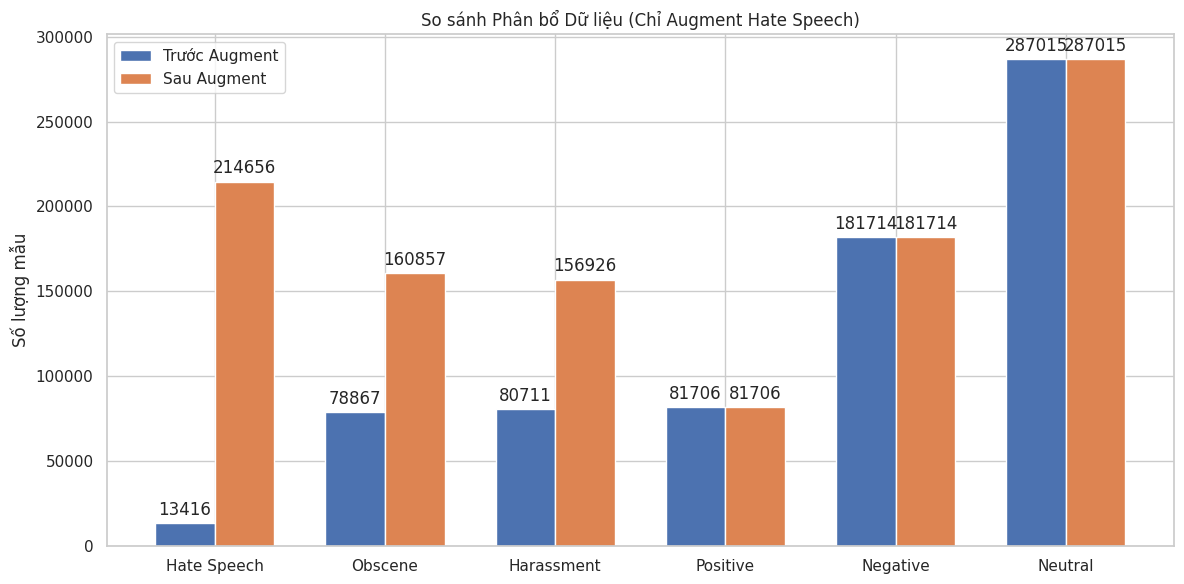

✅ Đã hoàn thành Augmentation chuyên biệt cho Hate Speech.

PHA 1: HUẤN LUYỆN WORD2VEC TRÊN TẬP TRAIN

PHA 2: HUẤN LUYỆN C-LSTM (20 EPOCHS | UNCERTAINTY WEIGHTING)

=> Epoch 1/20 | Train Loss: 0.3552
   [Auto-Weights] T1: 3.621 | T2A: 1.541 | T2B: 2.770

2. TIER 2A: CẢM XÚC (Chỉ chấm trên câu Clean)
              precision    recall  f1-score   support

    Negative       0.65      0.64      0.64     22697
     Neutral       0.75      0.78      0.76     35844
    Positive       0.75      0.70      0.72     10264

    accuracy                           0.72     68805
   macro avg       0.72      0.70      0.71     68805
weighted avg       0.72      0.72      0.72     68805


3. TIER 2B: CHI TIẾT ĐỘC HẠI
              precision    recall  f1-score   support

  Harassment       0.80      0.92      0.85     10036
     Obscene       0.86      0.85      0.86      9775
 Hate Speech       0.44      0.87      0.59      1727

   micro avg       0.78      0.88      0.83     21538
   macro avg     

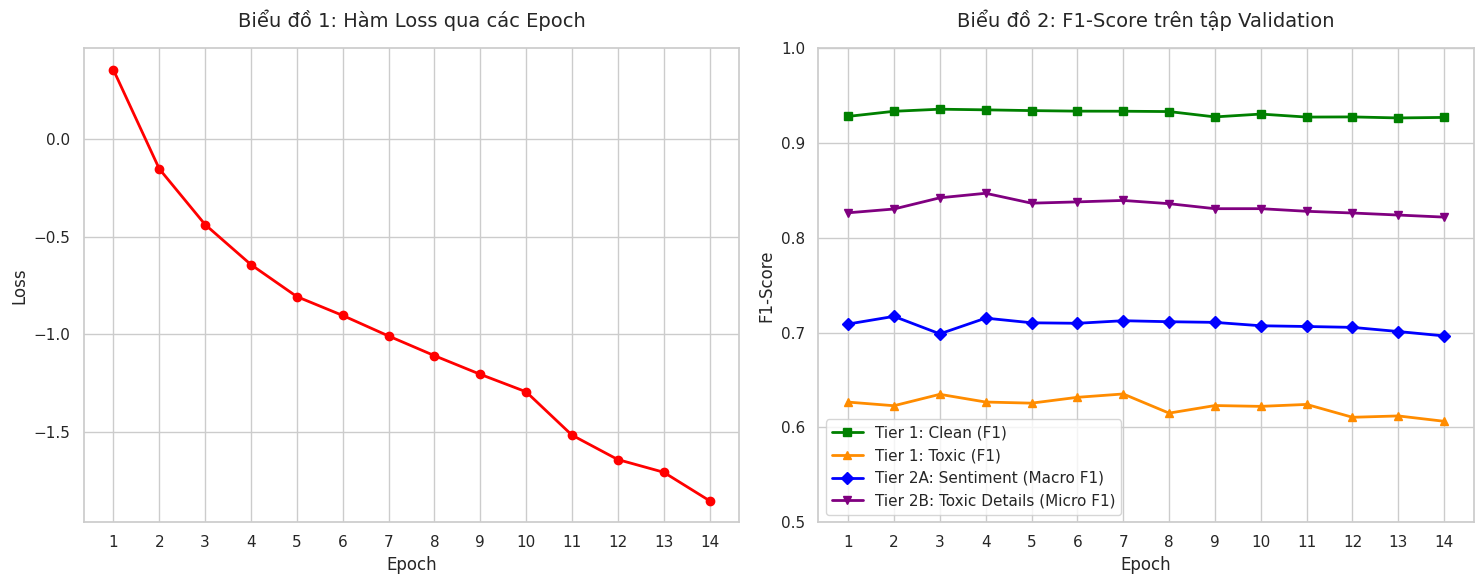

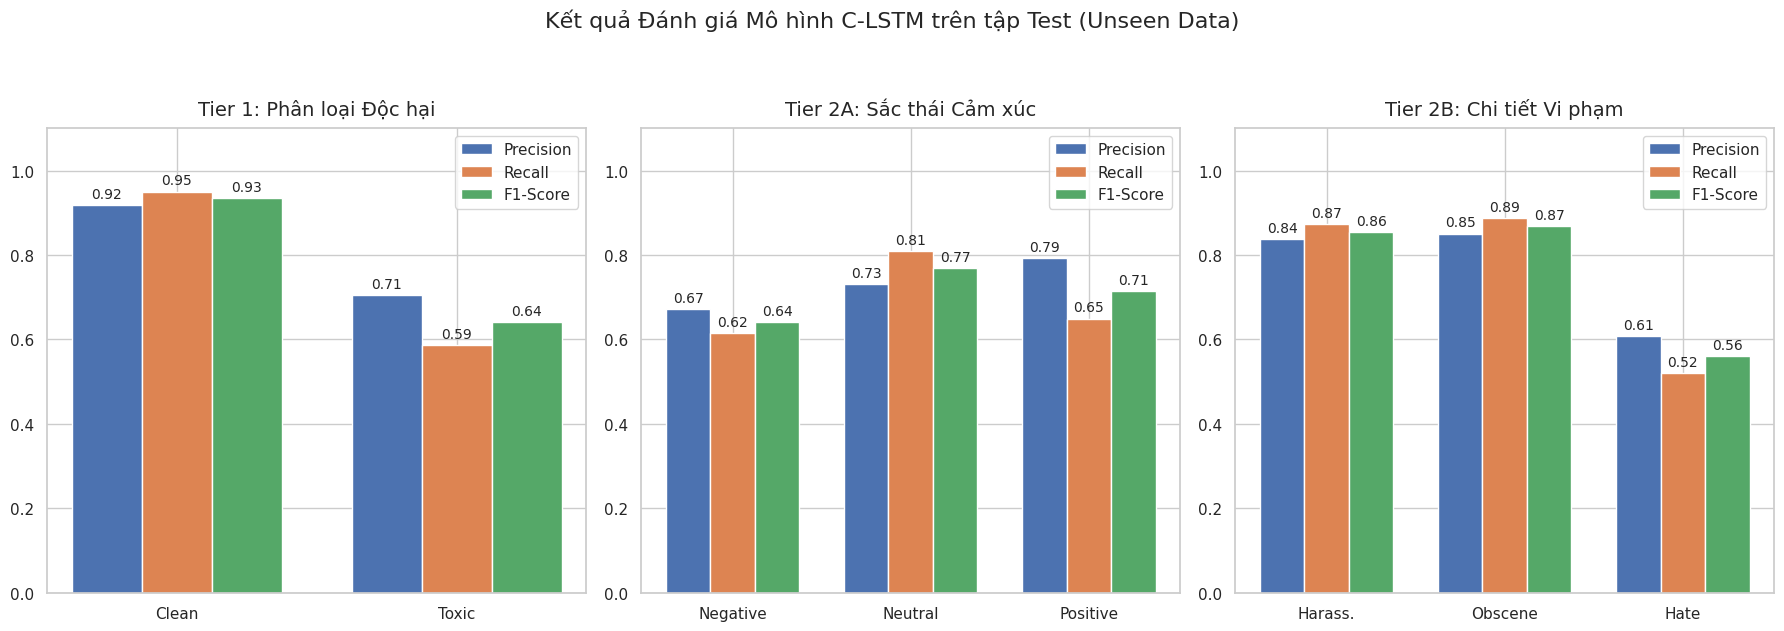

In [2]:
# =====================================================================
# CHẠY MAIN PIPELINE 
# =====================================================================
if __name__ == "__main__":
    ORIGINAL_CSV_PATH = "/kaggle/input/vietnamese-social-internet-comment-without-label/labeled_data.csv" 
    W2V_PATH, VOCAB_PATH = "/kaggle/working/custom_word2vec.npy", "/kaggle/working/vocab.json"
    
    # Bước 1: Chia dữ liệu
    train_csv, val_csv, test_csv = freeze_data_splits(ORIGINAL_CSV_PATH)
    
    # Bước 2: Data Augmentation (Chỉ Hate Speech)
    AUGMENTED_TRAIN_PATH = "/kaggle/working/train_data_augmented.csv"
    augment_and_plot(train_csv, AUGMENTED_TRAIN_PATH)
    
    # Bước 3: Huấn luyện Word2Vec (Lưu ý: Dùng TRAIN_CSV gốc)
    if not os.path.exists(W2V_PATH): train_skipgram_optimized(train_csv, W2V_PATH, VOCAB_PATH)
    else: print(f"Đã tìm thấy ma trận {W2V_PATH}. Chuyển thẳng sang TextCNN.")
    
    # Bước 4: Chuẩn bị Dataloader 
    with open(VOCAB_PATH, 'r', encoding='utf-8') as f: vocab = json.load(f)
    train_loader = build_dataloader(AUGMENTED_TRAIN_PATH, vocab, shuffle=True)
    val_loader, test_loader = build_dataloader(val_csv, vocab), build_dataloader(test_csv, vocab)
    
# Bước 5: Huấn luyện C-LSTM

class DynamicMultiTaskLoss(nn.Module):
    def __init__(self, num_tasks=3):
        super().__init__()
        # Khởi tạo tham số tự động học log(sigma^2) cho 3 tác vụ
        self.log_vars = nn.Parameter(torch.zeros(num_tasks))
        
    def forward(self, loss0, loss1, loss2):
        # Chặn (Clip) log_vars trong khoảng [-2.0, 2.0] để tránh nổ gradient hoặc mô hình "lười học"
        log_vars_clamped = torch.clamp(self.log_vars, min=-2.0, max=2.0)
        
        l0 = 0.5 * torch.exp(-log_vars_clamped[0]) * loss0 + 0.5 * log_vars_clamped[0]
        l1 = 0.5 * torch.exp(-log_vars_clamped[1]) * loss1 + 0.5 * log_vars_clamped[1]
        l2 = 0.5 * torch.exp(-log_vars_clamped[2]) * loss2 + 0.5 * log_vars_clamped[2]
        
        return l0 + l1 + l2

model = C_LSTM_Model(len(vocab), W2V_PATH).to(DEVICE)
mtl_loss = DynamicMultiTaskLoss(num_tasks=3).to(DEVICE)

# Nạp tham số của cả 2 mạng vào Optimizer
optimizer = torch.optim.Adam(list(model.parameters()) + list(mtl_loss.parameters()), 
                             lr=1e-3,
                             weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
history = {'loss': [], 'f1_clean': [], 'f1_toxic': [], 'f1_sent': [], 'f1_tdet': []}

MAX_EPOCHS = 20
PATIENCE = 7 
BEST_MODEL_PATH = "/kaggle/working/best_c_lstm_model.pth"

# Trọng số phạt cho Hate Speech (Cost-sensitive)
weight_t2b = torch.tensor([1.0, 1.0, 10.0]).to(DEVICE)

best_val_f1 = 0.0
patience_counter = 0
actual_epochs_run = []

print("\n" + "="*50)
print(f"PHA 2: HUẤN LUYỆN C-LSTM ({MAX_EPOCHS} EPOCHS | UNCERTAINTY WEIGHTING)")
print("="*50)

for epoch in range(1, MAX_EPOCHS + 1):
    actual_epochs_run.append(epoch)
    model.train()
    mtl_loss.train()
    total_loss = 0
    
    for x, yt, ys, yd in train_loader:
        x, yt, ys, yd = x.to(DEVICE), yt.to(DEVICE), ys.to(DEVICE), yd.to(DEVICE)
        optimizer.zero_grad()
        l_tox, l_sent, l_tdet = model(x)
        m_cln, m_tox = (yt == 0).float(), (yt == 1).float()
        
        # --- TÍNH TOÁN 3 LOSS ĐỘC LẬP ---
        # 1. Loss Tier 1 (Toxic/Clean)
        loss_t1 = F.binary_cross_entropy_with_logits(l_tox, yt)
        
        # 2. Loss Tier 2A (Sentiment - Chỉ tính trên câu Clean)
        loss_t2a = (F.cross_entropy(l_sent, ys, reduction='none', ignore_index=-1) * m_cln).sum() / (m_cln.sum() + 1e-8)
        
        # 3. Loss Tier 2B (Toxic Details - Chỉ tính trên câu Toxic + Pos Weight)
        loss_t2b = (F.binary_cross_entropy_with_logits(l_tdet, yd, reduction='none', pos_weight=weight_t2b).mean(1) * m_tox).sum() / (m_tox.sum() + 1e-8)
        
        # --- TỰ ĐỘNG CÂN BẰNG BẰNG UNCERTAINTY WEIGHTING ---
        loss = mtl_loss(loss_t1, loss_t2a, loss_t2b)
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    avg_loss = total_loss / len(train_loader)
    
    # In ra màn hình bộ trọng số (Log_vars) tự động học được
    print(f"\n=> Epoch {epoch}/{MAX_EPOCHS} | Train Loss: {avg_loss:.4f}")
    print(f"   [Auto-Weights] T1: {torch.exp(-mtl_loss.log_vars[0]).item():.3f} | T2A: {torch.exp(-mtl_loss.log_vars[1]).item():.3f} | T2B: {torch.exp(-mtl_loss.log_vars[2]).item():.3f}")
    
    rep_t1, rep_t2a, rep_t2b = evaluate_model(model, val_loader, f"Validation - Epoch {epoch}", print_report=True)
    
    # --- LƯU LỊCH SỬ VẼ BIỂU ĐỒ ---
    f1_t1 = rep_t1['Toxic']['f1-score'] if rep_t1 else 0
    f1_t2a = rep_t2a.get('macro avg', {}).get('f1-score', 0) if rep_t2a else 0
    f1_t2b = rep_t2b.get('micro avg', {}).get('f1-score', 0) if rep_t2b else 0
    
    history['loss'].append(avg_loss)
    history['f1_clean'].append(rep_t1['Clean']['f1-score'] if rep_t1 else 0)
    history['f1_toxic'].append(f1_t1)
    history['f1_sent'].append(f1_t2a)
    history['f1_tdet'].append(f1_t2b)
    
    # --- LOGIC EARLY STOPPING ---
    current_combined_f1 = (0.5 * f1_t1) + (0.3 * f1_t2a) + (0.2 * f1_t2b)
    scheduler.step(current_combined_f1)
    
    if current_combined_f1 > best_val_f1:
        print(f"🌟 Kỷ lục mới! F1 tổng hợp tăng từ {best_val_f1:.4f} lên {current_combined_f1:.4f}. Đang lưu Checkpoint...")
        best_val_f1 = current_combined_f1
        patience_counter = 0
        
        # Lưu CẢ model C-LSTM và mạng Uncertainty Loss
        checkpoint = {
            'model_state_dict': model.state_dict(),
            'mtl_loss_state_dict': mtl_loss.state_dict(),
            'best_f1': best_val_f1
        }
        torch.save(checkpoint, BEST_MODEL_PATH) 
    else:
        patience_counter += 1
        print(f"⚠️ Không có tiến bộ (Patience: {patience_counter}/{PATIENCE})")
        
    if patience_counter >= PATIENCE:
        print(f"\n🚨 KÍCH HOẠT EARLY STOPPING TẠI EPOCH {epoch}!")
        break 
        
# --- LOAD LẠI CHECKPOINT VÀ ĐI TEST ---
print(f"\nKhôi phục lại trọng số mô hình tốt nhất (Best Validation F1: {best_val_f1:.4f})...")
checkpoint = torch.load(BEST_MODEL_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
    
print("\n" + "="*50 + "\nNGHIỆM THU CUỐI CÙNG TRÊN TẬP TEST (UNSEEN DATA)\n" + "="*50)
test_dicts = evaluate_model(model, test_loader, "Test Data", print_report=True)
plot_training_results(actual_epochs_run, history, test_dicts)

In [3]:
import torch
import json
import numpy as np

# Đảm bảo đã load các class C-LSTM_Model và DynamicMultiTaskLoss từ code trước
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

class ToxicCommentPredictor:
    def __init__(self, model_path, vocab_path, w2v_path):
        print("⏳ Đang tải bộ não mô hình...")
        
        # 1. Load Từ điển
        with open(vocab_path, 'r', encoding='utf-8') as f:
            self.vocab = json.load(f)
            
        # 2. Khởi tạo lại C-LSTM
        self.model = C_LSTM_Model(len(self.vocab), w2v_path).to(DEVICE)
        
        # 3. Load Checkpoint (Lưu ý: File checkpoint của ta lưu cả model và loss)
        checkpoint = torch.load(model_path, map_location=DEVICE)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.model.eval() # Bật chế độ suy luận (Tắt Dropout)
        
        print("✅ Hệ thống AI đã sẵn sàng!")
        
    def preprocess(self, text):
        """Tiền xử lý câu văn giống hệt như lúc Train"""
        # Chuyển thành chữ thường và tách từ cơ bản
        words = str(text).lower().split()
        
        # Biến chữ thành số (Dùng <UNK> nếu từ mới tinh chưa từng học)
        seq = [self.vocab.get(w, self.vocab.get("<UNK>", 1)) for w in words]
        
        # Cắt hoặc đệm cho đủ 50 tokens
        seq = seq[:50] + [self.vocab.get("<PAD>", 0)] * max(0, 50 - len(seq))
        
        # Biến thành Tensor [Batch_size=1, Seq_len=50]
        return torch.tensor([seq], dtype=torch.long).to(DEVICE)
        
    def predict(self, text):
        # 1. Tiền xử lý
        input_tensor = self.preprocess(text)
        
        # 2. Suy luận
        with torch.no_grad():
            l_tox, l_sent, l_tdet = self.model(input_tensor)
            
            # --- TIER 1: TOXIC / CLEAN ---
            prob_tox = torch.sigmoid(l_tox).item()
            is_toxic = (prob_tox >= 0.38)
            tier1_result = "Tieu Cuc (Toxic)" if is_toxic else "Binh Thuong (Clean)"
            
            # --- TIER 2A: CẢM XÚC ---
            # Chỉ xét Cảm xúc nếu là câu Clean
            sentiment_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
            if not is_toxic:
                sent_idx = torch.argmax(torch.softmax(l_sent, dim=1)).item()
                tier2a_result = sentiment_map[sent_idx]
            else:
                tier2a_result = "N/A (Vi pham quy tac)"
                
            # --- TIER 2B: CHI TIẾT ĐỘC HẠI ---
            # Chỉ xét chi tiết độc hại nếu là câu Toxic
            tier2b_result = []
            if is_toxic:
                probs_tdet = torch.sigmoid(l_tdet)[0].cpu().numpy()
                
                # Cắt ngưỡng 0.5 cho Harassment và Obscene
                if probs_tdet[0] >= 0.5: tier2b_result.append(f"Harassment ({probs_tdet[0]:.0%})")
                if probs_tdet[1] >= 0.5: tier2b_result.append(f"Obscene ({probs_tdet[1]:.0%})")
                
                # [MẸO NHỎ]: Hạ ngưỡng Hate Speech xuống 0.4 để bắt nhạy hơn
                if probs_tdet[2] >= 0.4: tier2b_result.append(f"Hate Speech ({probs_tdet[2]:.0%})")
                
                if len(tier2b_result) == 0:
                    tier2b_result.append("Toxic (Khong ro chi tiet)")
            else:
                tier2b_result = ["N/A"]

        # 3. In kết quả đẹp mắt
        print("\n" + "-"*50)
        print(f"📝 BÌNH LUẬN: \"{text}\"")
        print("-" * 50)
        print(f"🔹 TIER 1 (Phân loại): {tier1_result} [Độ tin cậy: {prob_tox:.1%}]")
        print(f"🔹 TIER 2A (Cảm xúc) : {tier2a_result}")
        print(f"🔹 TIER 2B (Vi phạm) : {', '.join(tier2b_result)}")
        print("-" * 50)

# ==========================================
# TEST THỬ HỆ THỐNG
# ==========================================
# Khởi tạo 1 lần duy nhất
predictor = ToxicCommentPredictor(
    model_path="/kaggle/working/best_c_lstm_model.pth", 
    vocab_path="/kaggle/working/vocab.json", 
    w2v_path="/kaggle/working/custom_word2vec.npy"
)



⏳ Đang tải bộ não mô hình...
✅ Hệ thống AI đã sẵn sàng!


In [4]:
# Gõ các câu thử nghiệm vào đây!
test_sentences = [
    "Sản phẩm này xài ngon lắm, giao hàng cũng nhanh nữa.",
    "Hàng như cái quần què, mả cha nhà mày lừa đảo à",
    "Bọn dân 36 toàn lũ ăn cắp",  # Thử thách Hate Speech ẩn dụ
    "Mẹ mày thằng chó điên", 
    "Con cặc",
    "hihihi",
    "Ủng hộ",
    "Bắc kỳ ăn cá rô phi, ăn nhầm lựu đạn chết cha Bắc kỳ",
    "Má m dạy m tốt quá nên giờ m mới khôn như vậy",
    "Má t làm nông dân",
    "Cục cức",
    "dm",
    "đụ mẹ"
]

for sentence in test_sentences:
    predictor.predict(sentence)


--------------------------------------------------
📝 BÌNH LUẬN: "Sản phẩm này xài ngon lắm, giao hàng cũng nhanh nữa."
--------------------------------------------------
🔹 TIER 1 (Phân loại): Binh Thuong (Clean) [Độ tin cậy: 0.7%]
🔹 TIER 2A (Cảm xúc) : Positive
🔹 TIER 2B (Vi phạm) : N/A
--------------------------------------------------

--------------------------------------------------
📝 BÌNH LUẬN: "Hàng như cái quần què, mả cha nhà mày lừa đảo à"
--------------------------------------------------
🔹 TIER 1 (Phân loại): Tieu Cuc (Toxic) [Độ tin cậy: 100.0%]
🔹 TIER 2A (Cảm xúc) : N/A (Vi pham quy tac)
🔹 TIER 2B (Vi phạm) : Harassment (100%), Obscene (100%)
--------------------------------------------------

--------------------------------------------------
📝 BÌNH LUẬN: "Bọn dân 36 toàn lũ ăn cắp"
--------------------------------------------------
🔹 TIER 1 (Phân loại): Tieu Cuc (Toxic) [Độ tin cậy: 100.0%]
🔹 TIER 2A (Cảm xúc) : N/A (Vi pham quy tac)
🔹 TIER 2B (Vi phạm) : Obscene (100%

1. Đang load Từ điển và Dữ liệu Test...
2. Đang nạp Trọng số (Bộ não) tốt nhất của C-LSTM...
3. Bắt đầu chấm điểm Exact Match...
⏳ Đang quét Test Data để tính điểm Exact Match...


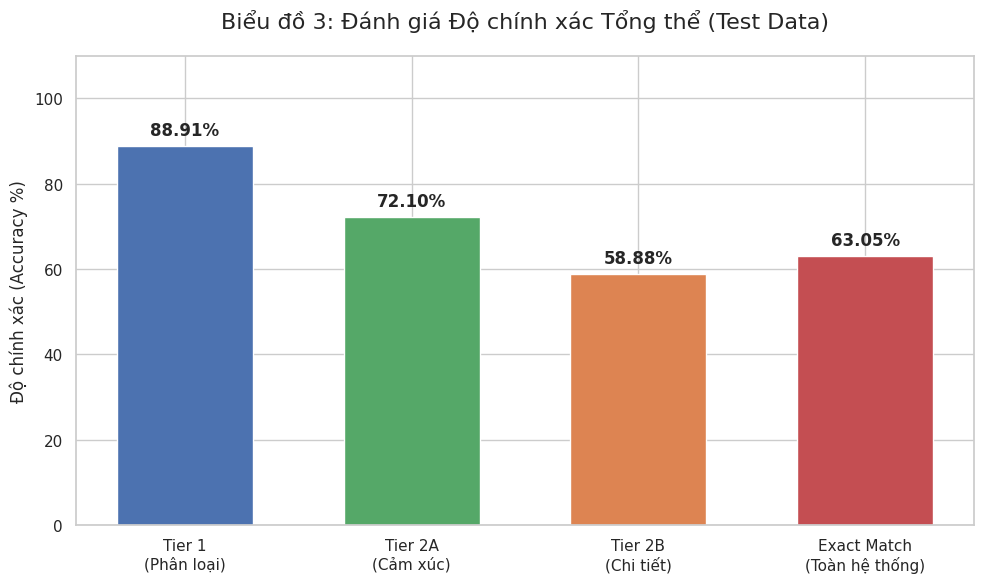


★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
🏆 BÁO CÁO TỔNG THỂ HỆ THỐNG (TEST DATA)
Tổng số câu đã duyệt        : 82,753
Số câu đoán khớp tuyệt đối  : 52,177
Exact Match Accuracy        : 63.05%
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★


In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import json
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Cài đặt giao diện
sns.set_theme(style="whitegrid")
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# ==========================================
# 1. KHAI BÁO LẠI CÁC CẤU TRÚC (BẮT BUỘC)
# ==========================================
class HierarchicalDataset(Dataset):
    def __init__(self, X, yt, ys, yd):
        self.X, self.yt, self.ys, self.yd = torch.tensor(X, dtype=torch.long), torch.tensor(yt, dtype=torch.float32), torch.tensor(ys, dtype=torch.long), torch.tensor(yd, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.yt[i], self.ys[i], self.yd[i]

def build_dataloader(csv_path, vocab, batch_size=512, shuffle=False):
    df = pd.read_csv(csv_path).dropna(subset=['text'])
    df['label_toxic'] = df['tier1_labels'].map({'Clean': 0, 'Toxic': 1}).fillna(0).astype(int)

    
    sentiment_map = df['tier2_labels'].map({'Negative': 0, 'Neutral': 1, 'Positive': 2})
    df['label_sentiment'] = np.where(df['tier1_labels'] == 'Clean', sentiment_map, -1)
    df['label_sentiment'] = df['label_sentiment'].fillna(-1).astype(int)
    
    
    def encode_toxic(label):
        if pd.isna(label) or label in ['Negative', 'Neutral', 'Positive']: return [0, 0, 0]
        return [1 if 'Harassment' in str(label) else 0, 1 if 'Obscene' in str(label) else 0, 1 if 'Hate Speech' in str(label) else 0]
    df['label_toxic_details'] = df['tier2_labels'].apply(encode_toxic)
    
    X_seq = np.array(df['text'].apply(lambda x: ([vocab.get(w, vocab["<UNK>"]) for w in str(x).split()][:50] + [vocab["<PAD>"]] * 50)[:50]).tolist())
    return DataLoader(HierarchicalDataset(X_seq, df['label_toxic'].values, df['label_sentiment'].values, np.array(df['label_toxic_details'].tolist())), batch_size=batch_size, shuffle=shuffle)

class C_LSTM_Model(nn.Module):
    def __init__(self, vocab_size, w2v_path):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, 300, padding_idx=0)
        self.emb.weight.data.copy_(torch.from_numpy(np.load(w2v_path)))
        self.lstm = nn.LSTM(300, 128, batch_first=True, bidirectional=True)
        self.convs = nn.ModuleList([nn.Conv1d(256, 100, k) for k in [3,4,5]])
        self.drop = nn.Dropout(0.5)
        self.h_tox, self.h_sent, self.h_tdet = nn.Linear(300, 1), nn.Linear(300, 3), nn.Linear(300, 3)

    def forward(self, x):
        lstm_out, _ = self.lstm(self.emb(x))
        cnn_in = lstm_out.permute(0, 2, 1) 
        feat = self.drop(torch.cat([F.max_pool1d(F.relu(c(cnn_in)), c(cnn_in).shape[2]).squeeze(2) for c in self.convs], 1))
        return self.h_tox(feat).squeeze(1), self.h_sent(feat), self.h_tdet(feat)

# ==========================================
# 2. HÀM ĐÁNH GIÁ TỔNG THỂ VÀ VẼ BIỂU ĐỒ
# ==========================================
def evaluate_and_plot_overall(model, dataloader, phase_name="Test Data"):
    model.eval()

    total_samples, exact_matches = 0, 0
    t1_correct, t2a_correct, t2a_total, t2b_exact_matches, t2b_total = 0, 0, 0, 0, 0

    print(f"⏳ Đang quét {phase_name} để tính điểm Exact Match...")
    with torch.no_grad():
        for x, yt, ys, yd in dataloader:
            x = x.to(DEVICE)
            l_tox, l_sent, l_tdet = model(x)

            # --- Lấy dự đoán ---
            pred_t1 = (torch.sigmoid(l_tox) >= 0.5).int().cpu().numpy()
            pred_t2a = torch.argmax(torch.softmax(l_sent, dim=1), dim=1).cpu().numpy()
            pred_t2b = (torch.sigmoid(l_tdet) >= 0.5).int().cpu().numpy()

            # --- Lấy nhãn thật ---
            true_t1 = yt.int().numpy()
            true_t2a = ys.numpy()
            true_t2b = yd.int().numpy()

            batch_size = len(true_t1)
            total_samples += batch_size

            # --- Logic chấm điểm Khớp tuyệt đối ---
            for i in range(batch_size):
                is_exact_match = False

                if pred_t1[i] == true_t1[i]: t1_correct += 1

                if true_t1[i] == 0:  # Nhãn gốc CLEAN
                    t2a_total += 1
                    if pred_t2a[i] == true_t2a[i]:
                        t2a_correct += 1
                        if pred_t1[i] == 0: is_exact_match = True

                elif true_t1[i] == 1:  # Nhãn gốc TOXIC
                    t2b_total += 1
                    if np.array_equal(pred_t2b[i], true_t2b[i]):
                        t2b_exact_matches += 1
                        if pred_t1[i] == 1: is_exact_match = True

                if is_exact_match: exact_matches += 1

    # Tính phần trăm
    overall_exact_acc = (exact_matches / total_samples) * 100
    t1_acc = (t1_correct / total_samples) * 100
    t2a_acc = (t2a_correct / t2a_total) * 100 if t2a_total > 0 else 0
    t2b_acc = (t2b_exact_matches / t2b_total) * 100 if t2b_total > 0 else 0

    # --- VẼ BIỂU ĐỒ ---
    metrics = ['Tier 1\n(Phân loại)', 'Tier 2A\n(Cảm xúc)', 'Tier 2B\n(Chi tiết)', 'Exact Match\n(Toàn hệ thống)']
    scores = [t1_acc, t2a_acc, t2b_acc, overall_exact_acc]
    colors = ['#4c72b0', '#55a868', '#dd8452', '#c44e52']

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(metrics, scores, color=colors, width=0.6)

    ax.set_title(f'Biểu đồ 3: Đánh giá Độ chính xác Tổng thể ({phase_name})', fontsize=16, pad=20)
    ax.set_ylabel('Độ chính xác (Accuracy %)', fontsize=12)
    ax.set_ylim(0, 110)

    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('overall_exact_match_performance.png', dpi=300)
    plt.show()

    print("\n" + "★"*50)
    print(f"🏆 BÁO CÁO TỔNG THỂ HỆ THỐNG ({phase_name.upper()})")
    print(f"Tổng số câu đã duyệt        : {total_samples:,}")
    print(f"Số câu đoán khớp tuyệt đối  : {exact_matches:,}")
    print(f"Exact Match Accuracy        : {overall_exact_acc:.2f}%")
    print("★"*50)

# ==========================================
# 3. THỰC THI LOAD MÔ HÌNH VÀ CHẤM ĐIỂM
# ==========================================
if __name__ == "__main__":
    # Đường dẫn file đã lưu
    TEST_CSV_PATH = "test_data.csv"
    VOCAB_PATH = "vocab.json"
    W2V_PATH = "custom_word2vec.npy"
    MODEL_PATH = "best_c_lstm_model.pth"

    if not os.path.exists(MODEL_PATH):
        print("🚨 Lỗi: Không tìm thấy file trọng số mô hình! Vui lòng kiểm tra lại đường dẫn.")
    else:
        print("1. Đang load Từ điển và Dữ liệu Test...")
        with open(VOCAB_PATH, 'r', encoding='utf-8') as f:
            vocab = json.load(f)

        test_loader = build_dataloader(TEST_CSV_PATH, vocab, batch_size=512, shuffle=False)

        print("2. Đang nạp Trọng số (Bộ não) tốt nhất của C-LSTM...")
        model = C_LSTM_Model(len(vocab), W2V_PATH).to(DEVICE)

        # Load map_location=DEVICE để đảm bảo chạy được cả trên CPU/GPU
        checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
        model.load_state_dict(checkpoint['model_state_dict'])

        print("3. Bắt đầu chấm điểm Exact Match...")
        evaluate_and_plot_overall(model, test_loader, phase_name="Test Data")

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, classification_report
import json

# ==========================================
# 0. CẤU HÌNH & ĐƯỜNG DẪN (Tùy chỉnh lại cho đúng môi trường của em)
# ==========================================
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {DEVICE}")

VAL_CSV_PATH = "val_data.csv"
TEST_CSV_PATH = "test_data.csv"
VOCAB_PATH = "vocab.json"
W2V_PATH = "custom_word2vec.npy"
MODEL_WEIGHTS_PATH = "best_c_lstm_model.pth"

MAX_LEN = 50 # Sửa lại theo đúng MAX_LEN em đã dùng lúc Train (50, 75, hoặc 100)

# ==========================================
# 1. ĐỊNH NGHĨA DATALOADER VÀ KIẾN TRÚC MÔ HÌNH
# ==========================================
class HierarchicalDataset(Dataset):
    def __init__(self, X, yt, ys, yd):
        self.X = torch.tensor(X, dtype=torch.long)
        self.yt = torch.tensor(yt, dtype=torch.float32)
        self.ys = torch.tensor(ys, dtype=torch.long)
        self.yd = torch.tensor(yd, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.yt[i], self.ys[i], self.yd[i]

def build_dataloader(csv_path, vocab, batch_size=512, shuffle=False):
    df = pd.read_csv(csv_path).dropna(subset=['text'])
    df['label_toxic'] = df['tier1_labels'].map({'Clean': 0, 'Toxic': 1}).fillna(-1).astype(int)

    sentiment_map = df['tier2_labels'].map({'Negative': 0, 'Neutral': 1, 'Positive': 2})
    df['label_sentiment'] = np.where(df['tier1_labels'] == 'Clean', sentiment_map, -1)
    df['label_sentiment'] = df['label_sentiment'].fillna(-1).astype(int)

    def encode_toxic(label):
        if pd.isna(label) or label in ['Negative', 'Neutral', 'Positive']: return [0, 0, 0]
        return [1 if 'Harassment' in str(label) else 0, 1 if 'Obscene' in str(label) else 0, 1 if 'Hate Speech' in str(label) else 0]
    df['label_toxic_details'] = df['tier2_labels'].apply(encode_toxic)

    X_seq = np.array(df['text'].apply(lambda x: ([vocab.get(w, vocab.get("<UNK>", 1)) for w in str(x).split()][:MAX_LEN] + [vocab.get("<PAD>", 0)] * MAX_LEN)[:MAX_LEN]).tolist())
    return DataLoader(HierarchicalDataset(X_seq, df['label_toxic'].values, df['label_sentiment'].values, np.array(df['label_toxic_details'].tolist())), batch_size=batch_size, shuffle=shuffle)

class C_LSTM_Model(nn.Module):
    def __init__(self, vocab_size, w2v_path):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, 300, padding_idx=0)
        self.emb.weight.data.copy_(torch.from_numpy(np.load(w2v_path)))
        self.lstm = nn.LSTM(300, 128, batch_first=True, bidirectional=True)
        self.convs = nn.ModuleList([nn.Conv1d(256, 100, k) for k in [3,4,5]]) # 128 filters
        self.drop = nn.Dropout(0.5)
        # Đã cập nhật 384 do đổi filter CNN lên 128
        self.h_tox, self.h_sent, self.h_tdet = nn.Linear(300, 1), nn.Linear(300, 3), nn.Linear(300, 3)

    def forward(self, x):
        lstm_out, _ = self.lstm(self.emb(x))
        cnn_in = lstm_out.permute(0, 2, 1)
        feat = self.drop(torch.cat([F.max_pool1d(F.relu(c(cnn_in)), c(cnn_in).shape[2]).squeeze(2) for c in self.convs], 1))
        return self.h_tox(feat).squeeze(1), self.h_sent(feat), self.h_tdet(feat)

# ==========================================
# 2. HÀM DÒ TÌM NGƯỠNG VÀ ĐÁNH GIÁ
# ==========================================
def find_best_thresholds(model, val_loader):
    model.eval()
    print("\n⏳ ĐANG DÒ TÌM NGƯỠNG VÀNG TRÊN TẬP VALIDATION...")
    all_l_tox, all_y_tox, all_l_tdet, all_y_tdet = [], [], [], []

    with torch.no_grad():
        for x, yt, ys, yd in val_loader:
            x = x.to(DEVICE)
            l_tox, _, l_tdet = model(x)

            all_l_tox.append(torch.sigmoid(l_tox).cpu().numpy())
            all_y_tox.append(yt.cpu().numpy())

            mask = (yt.cpu().numpy() == 1)
            if mask.sum() > 0:
                all_l_tdet.append(torch.sigmoid(l_tdet[mask]).cpu().numpy())
                all_y_tdet.append(yd.cpu().numpy()[mask])

    all_l_tox, all_y_tox = np.concatenate(all_l_tox), np.concatenate(all_y_tox)
    if len(all_l_tdet) > 0: all_l_tdet, all_y_tdet = np.vstack(all_l_tdet), np.vstack(all_y_tdet)

    thresholds_to_test = np.arange(0.1, 0.91, 0.05)

    best_t1_f1, best_t1_th = 0, 0.5
    for th in thresholds_to_test:
        preds = (all_l_tox >= th).astype(int)
        score = f1_score(all_y_tox, preds, zero_division=0)
        if score > best_t1_f1: best_t1_f1, best_t1_th = score, th
    print(f"👉 Tier 1 [Toxic]       : Ngưỡng tối ưu = {best_t1_th:.2f} (Val F1: {best_t1_f1:.4f})")

    best_t2b_thresholds = [0.5, 0.5, 0.5]
    label_names = ['Harassment', 'Obscene', 'Hate Speech']
    if len(all_l_tdet) > 0:
        for i in range(3):
            best_f1, best_th = 0, 0.5
            for th in thresholds_to_test:
                preds = (all_l_tdet[:, i] >= th).astype(int)
                score = f1_score(all_y_tdet[:, i], preds, zero_division=0)
                if score > best_f1: best_f1, best_th = score, th
            best_t2b_thresholds[i] = best_th
            print(f"👉 Tier 2B [{label_names[i]:<11}]: Ngưỡng tối ưu = {best_th:.2f} (Val F1: {best_f1:.4f})")
    return best_t1_th, best_t2b_thresholds

def evaluate_model_with_thresholds(model, dataloader, phase_name="Test Data", th_t1=0.5, th_t2b=[0.5, 0.5, 0.5]):
    model.eval()
    all_yt_true, all_yt_pred, all_ys_true, all_ys_pred, all_yd_true, all_yd_pred = [], [], [], [], [], []
    th_t2b = np.array(th_t2b)

    with torch.no_grad():
        for x, yt, ys, yd in dataloader:
            x = x.to(DEVICE)
            l_tox, l_sent, l_tdet = model(x)
            yt_np = yt.cpu().numpy()

            all_yt_true.extend(yt_np)
            all_yt_pred.extend((torch.sigmoid(l_tox) >= th_t1).int().cpu().numpy())

            clean_mask, tox_mask = (yt_np == 0), (yt_np == 1)
            if clean_mask.any():
                all_ys_true.extend(ys.cpu().numpy()[clean_mask])
                all_ys_pred.extend(torch.argmax(torch.softmax(l_sent, dim=1), dim=1).cpu().numpy()[clean_mask])
            if tox_mask.any():
                all_yd_true.extend(yd.cpu().numpy()[tox_mask])
                all_yd_pred.extend((torch.sigmoid(l_tdet).cpu().numpy()[tox_mask] >= th_t2b).astype(int))

    print(f"\n[BÁO CÁO {phase_name.upper()}]")
    print("1. TIER 1: TOXIC / CLEAN\n", classification_report(all_yt_true, all_yt_pred, target_names=["Clean", "Toxic"], zero_division=0))

    mask_clean = (np.array(all_ys_true) != -1)
    if mask_clean.any():
        print("2. TIER 2A: CẢM XÚC\n", classification_report(np.array(all_ys_true)[mask_clean], np.array(all_ys_pred)[mask_clean], target_names=["Negative", "Neutral", "Positive"], zero_division=0))
    if len(all_yd_true) > 0:
        print("3. TIER 2B: CHI TIẾT ĐỘC HẠI\n", classification_report(all_yd_true, all_yd_pred, target_names=["Harassment", "Obscene", "Hate Speech"], zero_division=0))

# ==========================================
# 3. CHẠY THỰC THI CHÍNH (MAIN PIPELINE)
# ==========================================
if __name__ == "__main__":
    # Load Vocab
    with open(VOCAB_PATH, 'r', encoding='utf-8') as f: vocab = json.load(f)

    # Load Data
    val_loader = build_dataloader(VAL_CSV_PATH, vocab)
    test_loader = build_dataloader(TEST_CSV_PATH, vocab)

    # Khởi tạo mô hình và nạp trọng số đã train
    model = C_LSTM_Model(len(vocab), W2V_PATH).to(DEVICE)
    # CODE MỚI ĐÃ SỬA
    checkpoint = torch.load(MODEL_WEIGHTS_PATH, map_location=DEVICE)

    # Chỉ lấy phần 'model_state_dict' bên trong gói Checkpoint để nạp vào mạng C-LSTM
    model.load_state_dict(checkpoint['model_state_dict'])
    print("✅ Đã load thành công trọng số mô hình.")

    # Dò ngưỡng và Đánh giá
    best_th_t1, best_th_t2b = find_best_thresholds(model, val_loader)

    print("\n" + "="*50)
    print("🚀 ĐÁNH GIÁ TRÊN TẬP TEST VỚI NGƯỠNG TỐI ƯU")
    print("="*50)
    evaluate_model_with_thresholds(model, test_loader, "Test Data", th_t1=best_th_t1, th_t2b=best_th_t2b)


[BÁO CÁO TEST DATA]
1. TIER 1: TOXIC / CLEAN
               precision    recall  f1-score   support

       Clean       0.94      0.92      0.93     68805
       Toxic       0.65      0.68      0.67     13948

    accuracy                           0.88     82753
   macro avg       0.79      0.80      0.80     82753
weighted avg       0.89      0.88      0.89     82753

2. TIER 2A: CẢM XÚC
               precision    recall  f1-score   support

    Negative       0.66      0.66      0.66     22767
     Neutral       0.76      0.77      0.76     35758
    Positive       0.75      0.70      0.72     10280

    accuracy                           0.72     68805
   macro avg       0.72      0.71      0.71     68805
weighted avg       0.72      0.72      0.72     68805

3. TIER 2B: CHI TIẾT ĐỘC HẠI
               precision    recall  f1-score   support

  Harassment       0.81      0.92      0.86     10050
     Obscene       0.83      0.91      0.87      9897
 Hate Speech       0.51      0.